## This Jupyter Python Notebook generates artifacts that are referenced within the document entitled...
## Introducing Full Sky (Sphere) Kinetics and Imaging [FSKI] ...
## Specifically the Figures that explain the orbital paths when FSKI is deployed at:
##     L2 and L3 with a relay satellite at L4
##     L4 and L5 orbiting ahead of Earth and behind Earth

## Instantiate lower level functions
## In the following 3-4 cells  


In [10]:
# Define the wavy-sine wave line function
def plot_wavy_line(p1, p2, amplitude, frequency, rqstd_color, num_points=200):
    """
    Generates and plots a sine wave between two points.

    :param p1: Start point (x1, y1)
    :param p2: End point (x2, y2)
    :param amplitude: The amplitude of the mini-sine wave.
    :param frequency: The number of oscillations (cycles) between the points.
    :param num_points: The number of points to generate for the smooth curve.
    """
    x1, y1 = p1
    x2, y2 = p2

    # 1. Create a linear path (the main direction of the line)
    #    Use np.linspace to get an array of x values between the two points
    x = np.linspace(x1, x2, num_points)
    y = np.linspace(y1, y2, num_points)

    # 2. Calculate the length and angle of the main line segment
    dx = x2 - x1
    dy = y2 - y1
    length = np.sqrt(dx**2 + dy**2)
    angle = np.arctan2(dy, dx)

    # 3. Generate the perpendicular oscillations (the mini-sine wave)
    #    The phase (np.linspace) goes from 0 to 2*pi*frequency
    #    The actual displacement is perpendicular to the main line
    wave_phase = np.linspace(0, 2 * np.pi * frequency, num_points)
    oscillations = amplitude * np.sin(wave_phase)

    # 4. Rotate and add the oscillations to the linear path
    #    Rotation matrix: x_rot = x*cos(angle) - y*sin(angle)
    #                     y_rot = x*sin(angle) + y*cos(angle)
    #    Here, the oscillations are 'y' in the local coordinate system
    new_x = x + oscillations * (-np.sin(angle))
    new_y = y + oscillations * (np.cos(angle))
    
    # 5. Plot the final wavy line
    ax.plot(new_x, new_y, color=rqstd_color)


In [11]:
# Define one function for X value
def CalcXWithCost(Radius, FrameNo, OrbitOffset):
    Angle = theta[FrameNo]
    #print(Angle)
    XVal = Radius * np.cos(Angle+OrbitOffset)
    #print(XVal)
    return XVal

In [7]:
!conda info --envs


# conda environments:
#
                       /Users/fredklich/Downloads/lsst_stack_v28/conda
base                 * /Users/fredklich/Downloads/lsst_stack_v28/conda/envs/lsst-scipipe-9.0.0
                       /Users/fredklich/anaconda3



In [12]:
# Define 2nd function for Y value
def CalcYWithSint(Radius, FrameNo, OrbitOffset):
    Angle = theta[FrameNo]
    #print(Angle)
    YVal = Radius * np.sin(Angle+OrbitOffset)
    #print(YVal)
    return YVal

## The next cells create an .mp4 movie animation that shows the orbital track of the FSKI arrays... 
## ....using Lagrange 2, 3 and 4 locations to facilitate operations.  
## Note that the radio sound effects reflected in the .pdf file animation were added later by the author.
## ....kudo's to those who can recall where the sound effects were sourced.


In [ ]:
# Golden #1a L2,L3,L4, make sure 3 or 4 functions are properly instantiated
# This cell plots the overlaps of each L and R celestial sphere with a colorized gray strip
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as ani
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.ndimage import rotate

# Setup Parameters for mpeg frame writers and other plotting radii, including the FSKTM image file
FFMpegWriter = ani.writers['ffmpeg']
writer       = ani.FFMpegWriter(fps=5)
# create a blank figure object (e.g. blank piece of paper)
FSKDots, ax = plt.subplots(layout='constrained')
FSKDots.set_size_inches(16,14)
FSKDots.patch.set_facecolor('gray') 

# Global artist references
l2_ann = [None]
l3_ann = [None]

fps, frames = 5, 180
theta = np.linspace(0, 6*np.pi, frames)  # Two times around the hamster cage is (4*np.pi)
R_earth, R_l2, R_l3, R_l4 = 1.0, 1.2, 1.0, 1.0 
#orig_img = plt.imread('/Users/fredklich/Downloads/FSKTrademarkx1.jpg')
#orig_img = plt.imread('/Users/fredklich/Downloads/ApplePagesNewFSKTM1.1.jpg')
orig_img = plt.imread('/Users/fredklich/Downloads/ApplePagesNewFSKTM1.3.jpg')

with writer.saving(FSKDots, "FSKDotsMovieWithLabelsL2L3L4a.mp4", 150):
    for f in range (0,frames):
        t = theta[f]
        deg = np.degrees(t)

        # Enable interactive mode and (re)instantiate the plot figure
        plt.ion()
        ax.set_title(' 3 Orbits, (3 Co-resident with Earth) \n')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlabel('\nX position in AU (left  and right)')    
        ax.set_ylabel('\nY position in AU (up    and down)')
        ax.set_facecolor('white') # Set canvas/background to white
 
        # Static Sun @center & Orbit of the earth
        ax.text(0,0,"Sun",color='black',fontsize=10, ha='center', va='center')
        ax.plot(0, 0, 'yo', markersize=40, markeredgecolor='orange', markeredgewidth=2 ) 
    
        # print(R_earth * np.cos(t), R_earth * np.sin(t))
        # Recalc the entire Earth trail points (X's and Y's) up to this value of "f"
        Xes = [CalcXWithCost(R_earth,t0,0) for t0 in range(0,f)]
        Yes = [CalcYWithSint(R_earth,t1,0) for t1 in range(0,f)]
        ax.plot(Xes[0:f], Yes[0:f], color='blue', label='Earth Orbit', linewidth=0.5, alpha=1)
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black', loc='center left', bbox_to_anchor=(1, 0.5))

        # L4 Satellite
        l4_angle = t + np.pi/3
        L4Text = ax.text(R_l4 * np.cos(l4_angle)+.03,  R_l4 * np.sin(l4_angle)+.03, "Lagrange\n Location 4\nSatellite", color='red', fontsize=10, fontweight='bold',ha='center', va='bottom')
        ax.plot(R_l4 * np.cos(l4_angle), R_l4 * np.sin(l4_angle), marker=r'$\boxtimes$', color='blue', label='L4-Satellite', markersize=12, markeredgecolor='white') 
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black', loc='center left', bbox_to_anchor=(1, 0.5))

        # Over plot a sine wave between Satellite and Earth
        plot_wavy_line((R_l4 * np.cos(l4_angle) , R_l4 * np.sin(l4_angle)) , (R_earth * np.cos(t), R_earth * np.sin(t)),  amplitude=0.03, frequency=1800, rqstd_color='red') # many cycles
        
        # Over plot a sine wave between L3 FSK Array and L4 Satellite
        plot_wavy_line((R_l3*np.cos(t+np.pi)   ,R_l3*np.sin(t+np.pi)),   (R_l4 * np.cos(l4_angle), R_l4 * np.sin(l4_angle)),  amplitude=0.03, frequency=2000, rqstd_color='blue') # many cycles

        # Over plot a sine wave between L2 FSK array and Earth
        plot_wavy_line((R_l2*np.cos(t), R_l2*np.sin(t)), (R_earth*np.cos(t), R_earth*np.sin(t)),  amplitude=0.03, frequency=1000, rqstd_color='green') # many cycles

        # L2 FSK Instrument One
        img_l2 = rotate(orig_img, deg + 180, cval=255, reshape=False) # cval eliminates black cornering
        l2_ann[0] = AnnotationBbox(OffsetImage(img_l2, zoom=.6), (R_l2*np.cos(t)     , R_l2*np.sin(t))   , frameon=False)
        ax.add_artist(l2_ann[0])
        #L2Text = ax.text(                                          R_l2*np.cos(t)+.07, R_l2*np.sin(t)+.20, "Lagrange\n Location 2\nFSK Array", color='red', fontsize=10, fontweight='bold',ha='center', va='bottom')
        L2Text = ax.text(                                           R_l2*np.cos(t)+.07, R_l2*np.sin(t)+.10, "Lagrange\n Location 2\nFSK Array", color='green', fontsize=10, fontweight='bold',ha='center', va='bottom')
        
        # Earth, lastly, plot the blue "Earth" dot and "Earth" annotation at the current x,y coordinates, on top of all other plotted parts/pieces
        EarthText    = ax.text(R_earth * np.cos(t)-.10, R_earth * np.sin(t)-.10, "Earth", color='blue', fontsize=10, ha='center', va='bottom')
        ax.plot(R_earth * np.cos(t)  ,R_earth * np.sin(t), 'bo', markersize=18, markeredgecolor='white')
        
        # Plot a line whose coodinates are Earth +90 degrees (point 1) and Earth -90 degrees (point 2)
        # Note: The Earth's radius is extended a tish so the eventual shading will also be extended
        # Calculate the coordinates of the two points
        x1E = (R_earth+1.2) * np.cos(t + np.pi/2 + .10)
        y1E = (R_earth+1.2) * np.sin(t + np.pi/2 + .10)
        x2E = (R_earth+1.2) * np.cos(t - np.pi/2 - .10)
        y2E = (R_earth+1.2) * np.sin(t - np.pi/2 - .10)
        point1 = (x1E,y1E)
        point2 = (x2E,y2E)
        ax.axline(xy1=point1, xy2=point2, color='b', linestyle='--', linewidth=2,label='Limit L2 FSKArray')
        #ax.plot([x1, x2], [y1, y2], marker='o', linestyle='-', color='b') # 'o' adds markers to the points
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black', loc='center left', bbox_to_anchor=(1, 0.5))
        
        # Recalc the entire L2 FSK Array trail points (X's and Y's) up to this value of "f"
        Xes = [CalcXWithCost(R_l2,t,0) for t in range(0,f)]
        Yes = [CalcYWithSint(R_l2,t,0) for t in range(0,f)]
        ax.plot(Xes[0:f], Yes[0:f], color='red', label='L2-FSK Array', linewidth=0.5, alpha=1)
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black', loc='center left', bbox_to_anchor=(1, 0.5))

        # L3 FSK Instrument Two
        img_l3 = rotate(orig_img, deg + 360, cval=255, reshape=False) # cval eliminates black cornering
        l3_ann[0] = AnnotationBbox(OffsetImage(img_l3, zoom=.6), (R_l3*np.cos(t+np.pi)    , R_l3*np.sin(t+np.pi))   , frameon=False)

        # Plot a line whose coodinates are L3 +90 degrees (point 1) and L3 -90 degrees (point 2)
        # Note: The L3's radius is extended a tish so the eventual shading will also be extended
        # Calculate the coordinates of the two points
        x1L3 = (R_l3+1.2) * np.cos(t + np.pi + np.pi/2 + .10)
        y1L3 = (R_l3+1.2) * np.sin(t + np.pi + np.pi/2 + .10)
        x2L3 = (R_l3+1.2) * np.cos(t + np.pi - np.pi/2 - .10)
        y2L3 = (R_l3+1.2) * np.sin(t + np.pi - np.pi/2 - .10)
        point1 = (x1L3,y1L3)
        point2 = (x2L3,y2L3)
        ax.axline(xy1=point1, xy2=point2, color='y', linestyle='--', linewidth=2,label='Limit L3 FSKArray')
        #ax.plot([x1, x2], [y1, y2], marker='o', linestyle='-', color='y') # 'o' adds markers to the points
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black', loc='center left', bbox_to_anchor=(1, 0.5))

        #Generage polygon (in correct ORDER) area amidst the four x,y coordinates
        XCoords = [x1E,x2L3,x1L3,x2E]
        YCoords = [y1E,y2L3,y1L3,y2E]
        # Fill the area using ax.fill() with grey
        ax.fill(XCoords, YCoords, facecolor='grey', alpha=0.3, label='Overlap FoV L2,L3')
        ax.add_artist(l3_ann[0])
        #L3Text = ax.text(                                          R_l3*np.cos(t+np.pi)+.03, R_l3*np.sin(t+np.pi)+.18, "Lagrange\n Location 3\nFSK Array", color='green', fontsize=10, fontweight='bold',ha='center', va='bottom')
        L3Text = ax.text(                                           R_l3*np.cos(t+np.pi)+.03, R_l3*np.sin(t+np.pi)+.10, "Lagrange\n Location 3\nFSK Array", color='blue', fontsize=10, fontweight='bold',ha='center', va='bottom')
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black', loc='center left', bbox_to_anchor=(1, 0.5))

        # Recalc the entire L3 FSK Array trail points (X's and Y's) up to this value of "f"
        Xes = [CalcXWithCost(R_l3,t,np.pi) for t in range(0,f)]
        Yes = [CalcYWithSint(R_l3,t,np.pi) for t in range(0,f)]
        ax.plot(Xes[0:f], Yes[0:f], color='blue', label='L3-FSK Array', linewidth=0.5, alpha=1)
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black', loc='center left', bbox_to_anchor=(1, 0.5))
        
        # Add the frame to the movie file, after printing out the "i" index value
        print(f, "..Still Generator-ing", end="\r")
        writer.grab_frame()
        
        # Force the figure to refresh using plt.pause(interval) to handle the redrawing and GUI events
        if l2_ann[0]: l2_ann[0].remove()
        if l3_ann[0]: l3_ann[0].remove()
        L2Text.remove()    # Now that we've "grabbed" the frame, let's remove the above iteration of the ax.text plotteration.  
        L3Text.remove()    # Same, again, for L3 ax.text plottimigation
        L4Text.remove()    # Same, again, for L4 ax.text plottimigation  
        EarthText.remove() # Same, again, for L4 ax.text plottimigation          
        ax.cla()

os.system('say "Fred, you L2 L3 L4 with overlap plot plucker,,, your script has completed"'); 

# 6. Disable interactive mode at the end to keep the window open
#plt.ioff()
#plt.show()
    

## This next cell also gens an .mp4 file that shows an optional deployment of the FSK Arrays....
## ....at the Lagrange locations L4 and L5, 60 degrees ahead of Earth's orbital path...
## ....and 60 degrees behind the Earth's orbital path
## Note that the radio sound effects reflected in the .pdf file animation were added later by the author.
## ....kudo's to those who can recall where the sound effects were sourced.

In [ ]:
# Golden #2, L4,L5, make sure 3 or 4 functions are properly instantiated
# Fifth draft to generate a .mp4 movie file of the frames from the for loop at Lagrange locations L4 and L5.
# FSK work cell F to plot a squiggley sine wave between the major points....
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as ani
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.ndimage import rotate

# Setup Parameters for mpeg frame writers and other plotting radii, including the FSKTM image file
FFMpegWriter = ani.writers['ffmpeg']
writer       = ani.FFMpegWriter(fps=5)
# create a blank figure object (e.g. blank piece of paper)
FSKDots, ax = plt.subplots(layout='constrained') # Use constrained layout
FSKDots.set_size_inches(16,14)
FSKDots.patch.set_facecolor('gray') 

# Global artist references
l2_ann = [None]
l3_ann = [None]

fps, frames = 5, 180
theta = np.linspace(0, 6*np.pi, frames)  # Two times around the hamster cage is (4*np.pi)
R_earth, R_l2, R_l3, R_l4, R_l5 = 1.0, 1.2, 1.0, 1.0, 1.0
#orig_img = plt.imread('/Users/fredklich/Downloads/FSKTrademarkx1.jpg')
#orig_img = plt.imread('/Users/fredklich/Downloads/ApplePagesNewFSKTM1.1.jpg')
orig_img = plt.imread('/Users/fredklich/Downloads/ApplePagesNewFSKTM1.3.jpg')

with writer.saving(FSKDots, "FSKDotsMovieWithLabelsL4L5a.mp4", 150):
    for f in range (0,frames):
        t = theta[f]
        deg = np.degrees(t)

        # Enable interactive mode and (re)instantiate the plot figure
        plt.ion()
        ax.set_title(' 3 Orbits, all co-resident with Earth  \n')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlabel('\nX position in AU (left  and right)')    
        ax.set_ylabel('\nY position in AU (up    and down)')
        ax.set_facecolor('white') # Set canvas/background to white
 
        # Static Sun @center & Orbit of the earth
        ax.text(0,0,"Sun",color='black',fontsize=10, ha='center', va='center')
        ax.plot(0, 0, 'yo', markersize=40, markeredgecolor='orange', markeredgewidth=2 ) 
    
        # print(R_earth * np.cos(t), R_earth * np.sin(t))
        # Recalc the entire Earth trail points (X's and Y's) up to this value of "f"
        Xes = [CalcXWithCost(R_earth,t0,0) for t0 in range(0,f)]
        Yes = [CalcYWithSint(R_earth,t1,0) for t1 in range(0,f)]
        ax.plot(Xes[0:f], Yes[0:f], color='blue', label='Earth Orbit', linewidth=0.5, alpha=1)
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black',loc='center left', bbox_to_anchor=(1, 0.5))

        # L4 FSK Array
        l4_angle = t + np.pi/3
        L4Text = ax.text(R_l4 * np.cos(l4_angle)+.07,  R_l4 * np.sin(l4_angle)+.10, "Lagrange\n Location 4\nFSK Array", color='red', fontsize=10, fontweight='bold',ha='center', va='bottom')
        ax.plot(R_l4 * np.cos(l4_angle), R_l4 * np.sin(l4_angle), color='blue', label='L4-FSK Array', markersize=12, markeredgecolor='white') 
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black',loc='center left', bbox_to_anchor=(1, 0.5))

        # L4 Annotated/rotated image
        img_l2 = rotate(orig_img, deg + 240, cval=255, reshape=False) # cval eliminates black cornering
        #l2_ann[0] = AnnotationBbox(OffsetImage(img_l2, zoom=.6), (R_l4*np.cos(t)            , R_l4*np.sin(t))          , frameon=False)
        l2_ann[0] = AnnotationBbox(OffsetImage(img_l2, zoom=.6), (R_l4*np.cos(l4_angle)     , R_l4*np.sin(l4_angle))   , frameon=False)        
        ax.add_artist(l2_ann[0])

        # L5 FSK Array
        l5_angle = t - np.pi/3
        L5Text = ax.text(R_l5 * np.cos(l5_angle)+.07,  R_l5 * np.sin(l5_angle)+.10, "Lagrange\n Location 5\nFSK Array", color='green', fontsize=10, fontweight='bold',ha='center', va='bottom')
        ax.plot(R_l5 * np.cos(l5_angle), R_l5 * np.sin(l5_angle), color='blue', label='L5-FSK Array', markersize=12, markeredgecolor='white') 
        ax.legend(frameon=True, facecolor='white', edgecolor='white', labelcolor='black',loc='center left', bbox_to_anchor=(1, 0.5))

        # L5 Annotated/rotated image
        img_l2 = rotate(orig_img, deg + 120, cval=255, reshape=False) # cval eliminates black cornering
        #l2_ann[0] = AnnotationBbox(OffsetImage(img_l2, zoom=.6), (R_l4*np.cos(t)            , R_l4*np.sin(t))          , frameon=False)
        l2_ann[0] = AnnotationBbox(OffsetImage(img_l2, zoom=.6), (R_l5*np.cos(l5_angle)     , R_l5*np.sin(l5_angle))   , frameon=False)        
        ax.add_artist(l2_ann[0])
     
        # Over plot a sine wave between L5 Satellite and Earth
        plot_wavy_line((R_l5 * np.cos(l5_angle) , R_l5 * np.sin(l5_angle)) , (R_earth * np.cos(t), R_earth * np.sin(t)),  amplitude=0.03, frequency=1800, rqstd_color='green') # many cycles
        
        # Over plot a sine wave between L4 Satellite and Earth
        plot_wavy_line((R_l4 * np.cos(l4_angle) , R_l4 * np.sin(l4_angle)) , (R_earth * np.cos(t), R_earth * np.sin(t)),  amplitude=0.03, frequency=1800, rqstd_color='red') # many cycles
        
        # Earth, lastly, plot the blue "Earth" dot and "Earth" annotation at the current x,y coordinates, on top of all other plotted parts/pieces
        EarthText    = ax.text(R_earth * np.cos(t)-.10, R_earth * np.sin(t)-.10, "Earth", color='blue', fontsize=10, ha='center', va='bottom')
        ax.plot(R_earth * np.cos(t)  ,R_earth * np.sin(t), 'bo', markersize=18, markeredgecolor='white')

        # Add the frame to the movie file, after printing out the "i" index value
        print(f, "..Still Generator-ing", end="\r")
        writer.grab_frame()
        
        # Force the figure to refresh using plt.pause(interval) to handle the redrawing and GUI events
        if l2_ann[0]: l2_ann[0].remove()
        if l3_ann[0]: l3_ann[0].remove()
        #L2Text.remove()    # Now that we've "grabbed" the frame, let's remove the above iteration of the ax.text plotteration.  
        #L3Text.remove()    # Same, again, for L3 ax.text plottimigation
        #L4Text.remove()    # Same, again, for L4 ax.text plottimigation  
        EarthText.remove() # Same, again, for L4 ax.text plottimigation          
        ax.cla()

os.system('say "Fred, you L4 L5 plucker,,, your script has completed"'); 

# 6. Disable interactive mode at the end to keep the window open
#plt.ioff()
#plt.show()
    

## This cell generates yet another .mp4 movie animation depicting the Terresterial deployment...
## of the FSKI wherein all the faces of the Goldberg Polyhedron are included to facilitate full
## sky coverage horizon-to-horizon for any specific location on Earth.

Rendering Circular Tapered Goldberg...
Saved: goldberg_circular_tapereda.mp4


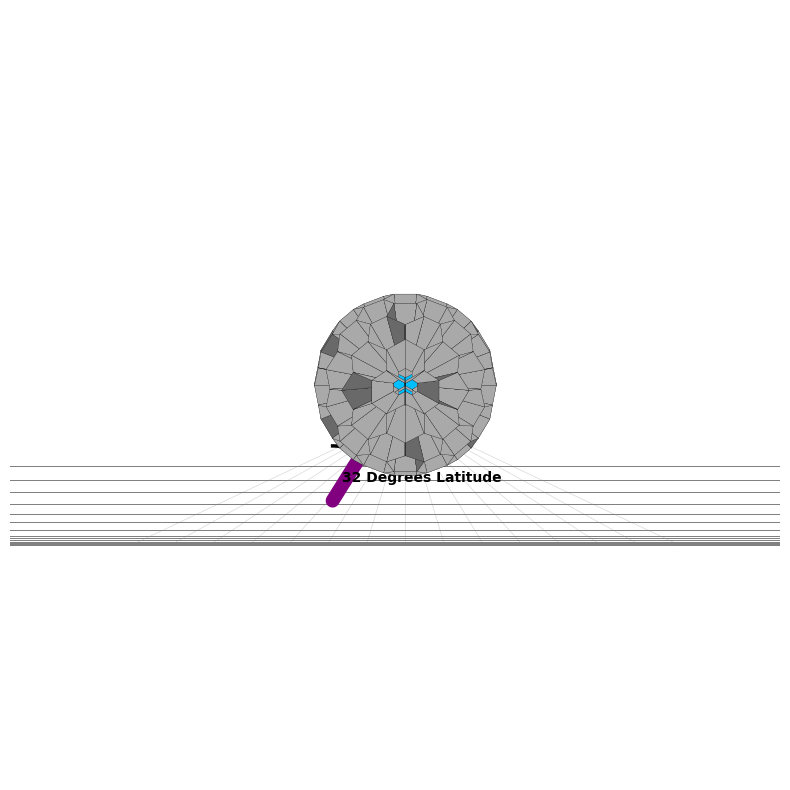

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import SphericalVoronoi, ConvexHull

def get_gray_chamber_geometry(depth=0.4, scale=0.6):
    phi = (1 + np.sqrt(5)) / 2
    verts = np.array([[-1,phi,0],[1,phi,0],[-1,-phi,0],[1,-phi,0],
                      [0,-1,phi],[0,1,phi],[0,-1,-phi],[0,1,-phi],
                      [phi,0,-1],[phi,0,1],[-phi,0,-1],[-phi,0,1]])
    hull = ConvexHull(verts)
    seeds = []
    for simplex in hull.simplices:
        v1, v2, v3 = verts[simplex]
        for i in range(4):
            for j in range(4 - i):
                k = 3 - i - j
                p = (i*v1 + j*v2 + k*v3) / 3
                if np.linalg.norm(p) > 0.1: seeds.append(p / np.linalg.norm(p))
    seeds = np.unique(np.array(seeds).round(6), axis=0)
    sv = SphericalVoronoi(seeds)
    sv.sort_vertices_of_regions()
    faces_data = []
    for region in sv.regions:
        ov, iv = sv.vertices[region], sv.vertices[region] * (1.0 - depth) * scale
        is_p = (len(region) == 5)
        f_c, w_c = ('gold' if is_p else 'deepskyblue'), ('dimgray' if is_p else 'darkgray')
        walls = [np.array([ov[i], ov[(i+1)%len(ov)], iv[(i+1)%len(ov)], iv[i]]) for i in range(len(ov))]
        faces_data.append({'inner': iv, 'walls': walls, 'floor_color': f_c, 'wall_color': w_c})
    return faces_data

def get_rot_matrix(axis, theta):
    axis = axis / np.linalg.norm(axis)
    ux, uy, uz = axis
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c + ux**2*(1-c), ux*uy*(1-c) - uz*s, ux*uz*(1-c) + uy*s],
        [uy*ux*(1-c) + uz*s, c + uy**2*(1-c), uy*uz*(1-c) - ux*s],
        [uz*ux*(1-c) - uy*s, uz*uy*(1-c) + ux*s, c + uz**2*(1-c)]
    ])

# --- Setup ---
fig = plt.figure(figsize=(10, 10), facecolor='white')
ax = fig.add_subplot(111, projection='3d')

# FORCE CIRCULAR: Orthographic projection + Equal aspect
ax.set_proj_type('ortho')
ax.set_box_aspect((1, 1, 1)) 

tilt_angle = np.radians(32)
tilted_axis = np.array([np.sin(tilt_angle), 0, np.cos(tilt_angle)])
z_floor = -1.5

# MANUALLY TAPERED GRID: To show distance while in Ortho mode
grid_limit = 10
for i in np.linspace(-3, 3, 15):
    # Vertical lines that converge toward a vanishing point at the top
    ax.plot([i, i*0.2], [-3, 10], [z_floor, z_floor], color='gray', lw=0.5, alpha=0.3)
    # Horizontal lines that get closer together as they go "up"
    h_z = z_floor
    h_y = np.linspace(-3, 10, 15)**2 / 10 - 3 # Quadratic spacing for perspective feel
    for y_val in h_y:
        ax.plot([-5, 5], [y_val, y_val], [h_z, h_z], color='gray', lw=0.5, alpha=0.3)

# Purple Pole
p_ground = tilted_axis * z_floor
p_top = tilted_axis * -1.0
ax.plot([p_ground[0], p_top[0]], [p_ground[1], p_top[1]], [p_ground[2], p_top[2]],
        color='purple', lw=10, solid_capstyle='round')

# Latitude Arc and Text
arc_radius, arc_angles = 0.6, np.linspace(0, tilt_angle, 50)
ax.plot(p_ground[0] + arc_radius * np.sin(arc_angles),
        p_ground[1] + np.zeros_like(arc_angles),
        p_ground[2] + arc_radius * np.cos(arc_angles), color='black', lw=2.5)
ax.text(p_ground[0] + 0.1, p_ground[1], p_ground[2] + 0.2, "32 Degrees Latitude",
        color='black', fontsize=10, fontweight='bold')

faces_info = get_gray_chamber_geometry()
wall_coll = Poly3DCollection([], edgecolors='black', linewidths=0.15)
floor_coll = Poly3DCollection([], edgecolors='black', linewidths=0.15) 
ax.add_collection3d(wall_coll)
ax.add_collection3d(floor_coll)

# STRAIGHT-ON POV
ax.set_xlim([-2.5, 2.5]); ax.set_ylim([-2.5, 2.5]); ax.set_zlim([-2.5, 2.5])
ax.view_init(elev=5, azim=-90) # Low elevation for floor-level feel
ax.set_axis_off()

def update(frame):
    theta = -(frame / 120) * 2 * np.pi
    R = get_rot_matrix(tilted_axis, theta)
    w_v, w_c, f_v, f_c = [], [], [], []
    for f in faces_info:
        for w in f['walls']:
            w_v.append(np.dot(w, R.T))
            w_c.append(f['wall_color'])
        f_v.append(np.dot(f['inner'], R.T))
        f_c.append(f['floor_color'])
    wall_coll.set_verts(w_v); wall_coll.set_facecolors(w_c)
    floor_coll.set_verts(f_v); floor_coll.set_facecolors(f_c)
    return wall_coll, floor_coll

print("Rendering Circular Tapered Goldberg...")
ani = FuncAnimation(fig, update, frames=120, interval=40, blit=False)
writer = FFMpegWriter(fps=30, bitrate=5000)
ani.save('goldberg_circular_tapereda.mp4', writer=writer)
print("Saved: goldberg_circular_tapereda.mp4")


## This next series of cells demonstrates target separation in/on the celestial sphere at 2.5, 1.25 and .625 degrees of separation.
## The ICRS coordinate scheme is used here.

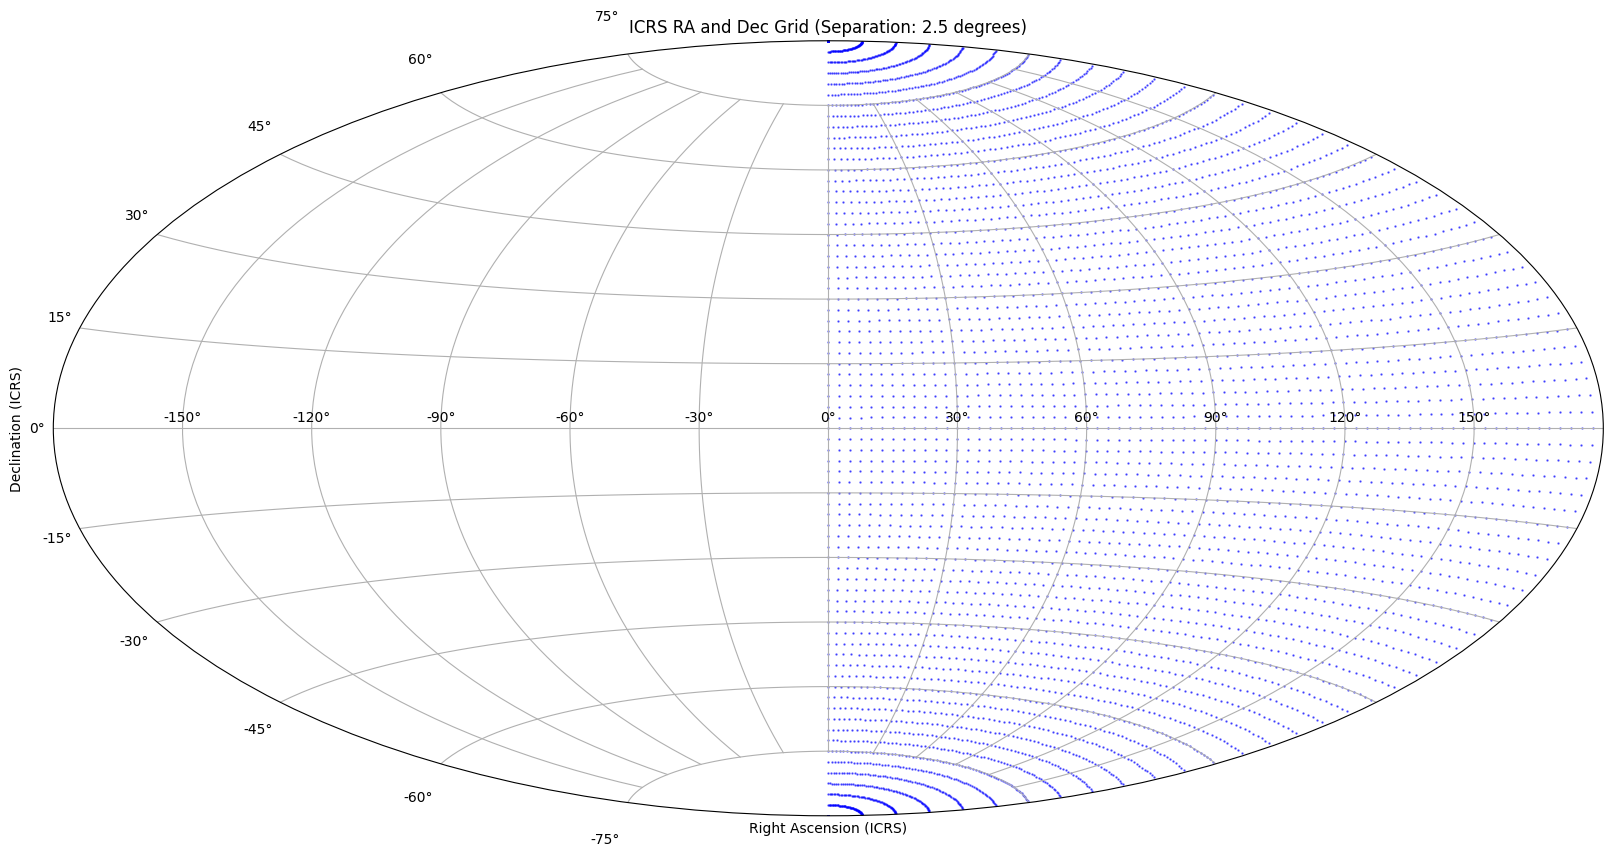

In [3]:
# Plot target set for 1/2 of celestial sphere 
# Will each target separated by 2.5 degrees
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u

def plot_full_sky_grid(separation_deg):
    """
    Generates and plots a full-sky grid of RA and Dec points in the ICRS frame.

    Args:
        separation_deg (float): The desired separation between grid points in degrees.
    """
    # 1. Generate a grid of RA and Dec points
    # RA goes from 0 to 360 degrees
    ra_range = np.arange(0, 180, separation_deg) * u.deg

    # Dec goes from -90 to 90 degrees.
    dec_range = np.arange(-90, 91, separation_deg) * u.deg

    # Create a meshgrid to get all combinations of RA and Dec
    ra_grid, dec_grid = np.meshgrid(ra_range, dec_range)

    # Flatten the grids for use in SkyCoord
    ra_flat = ra_grid.flatten()
    dec_flat = dec_grid.flatten()

    # 2. Create an Astropy SkyCoord object
    # Specify the frame as 'icrs'. Astropy defaults to ICRS for (ra, dec)
    coords = SkyCoord(ra=ra_flat, dec=dec_flat, frame='icrs')

    # 3. Plot the points using Matplotlib with an Aitoff projection
    fig = plt.figure(figsize=(20, 12))
    # Using 'aitoff' projection for a full-sky view
    ax = fig.add_subplot(111, projection="aitoff")

    # Plotting requires wrapping the RA to be in the range [-180, 180] for Aitoff projection
    # Matplotlib's aitoff projection automatically handles some of this, but it's good practice
    # to use the wrapped angles from astropy to be sure.
    # RA is traditionally plotted such that it increases to the left.
    ax.scatter(coords.ra.wrap_at('180d').radian, coords.dec.radian, s=.5, color='blue',alpha=0.6)

    # Customize the plot
    ax.set_title(f'ICRS RA and Dec Grid (Separation: {separation_deg} degrees)')
    ax.set_xlabel('Right Ascension (ICRS)')
    ax.set_ylabel('Declination (ICRS)')
    ax.grid(True)

    # Show the plot
    plt.show()

# Run the function with a specified degree of separation
plot_full_sky_grid(2.50)


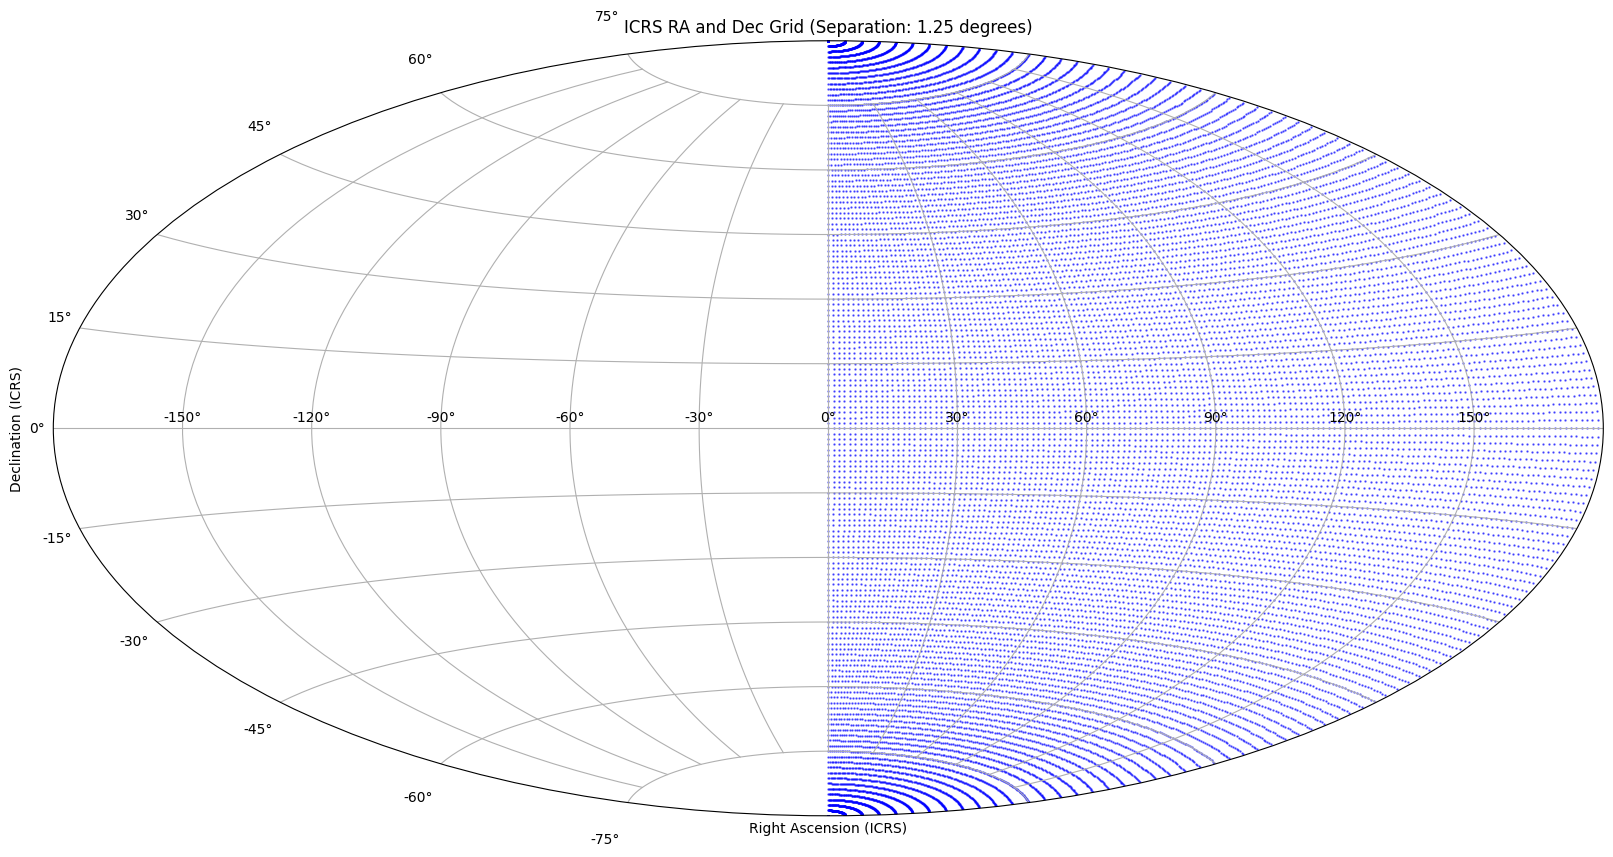

In [6]:
# And again, with separation at 1.25 degrees
plot_full_sky_grid(1.25)

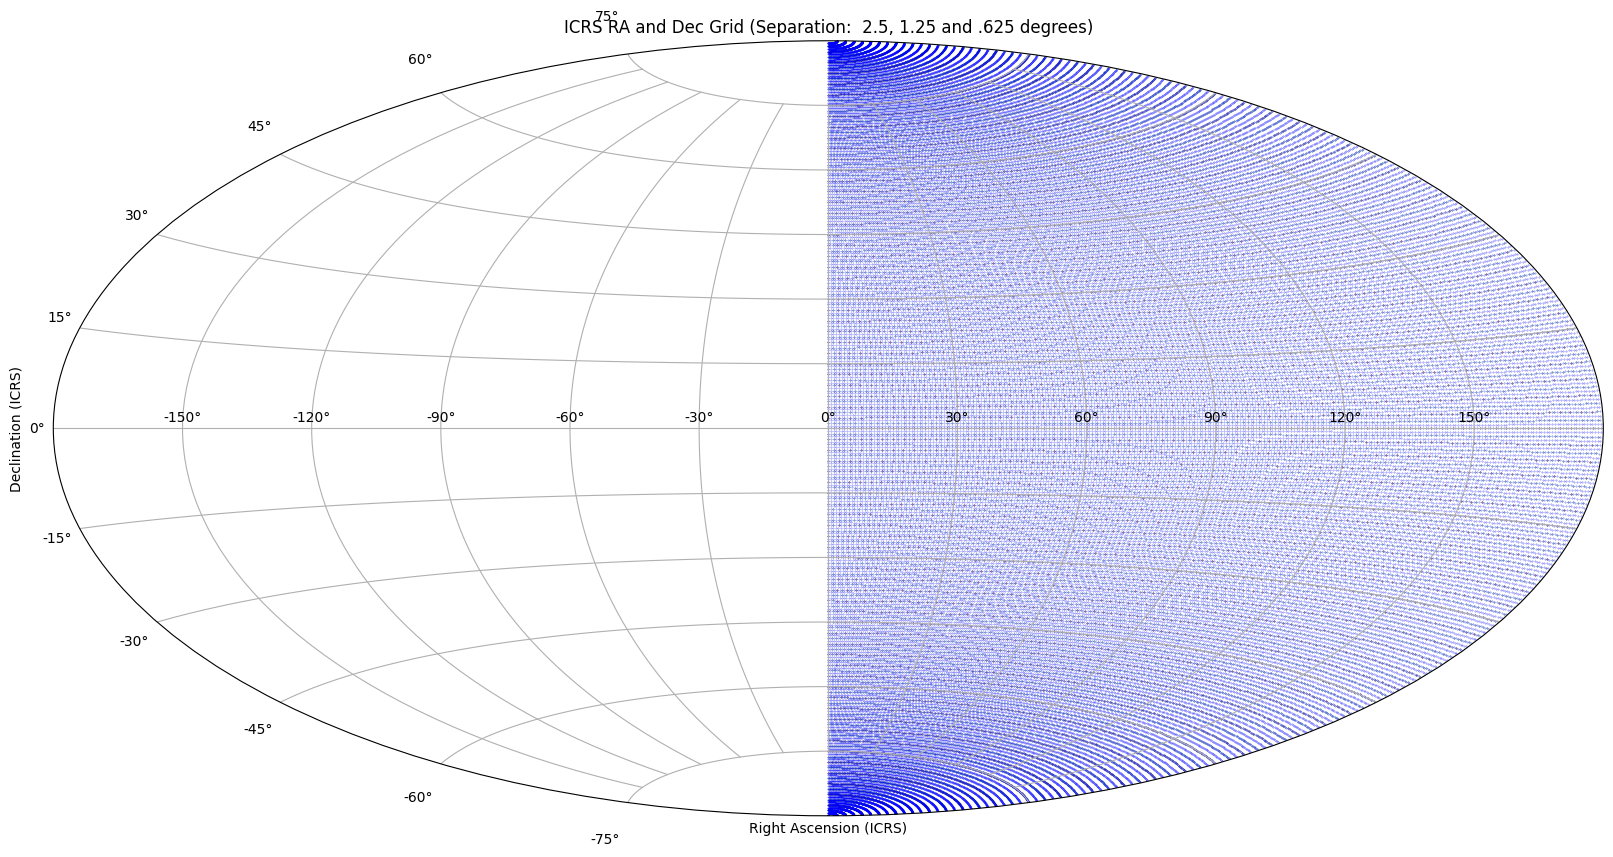

In [8]:
# This plot includes target separations of 2.5 degrees, 1.25 degrees AND 0.625 degrees
# 
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u

def plot_full_sky_grid(separation_deg):
    """
    Generates and plots a full-sky grid of RA and Dec points in the ICRS frame.

    Args:
        separation_deg (float): The desired separation between grid points in degrees.
    """
    # 1. Generate a grid of RA and Dec points
    # RA goes from 0 to 360 degrees
    ra_range            = np.arange(0, 180, 2.500)  * u.deg
    split_ra_range      = np.arange(0, 180, 1.250)  * u.deg 
    split_625_ra_range  = np.arange(0, 180, 0.625)  * u.deg

    # Dec goes from -90 to 90 degrees.
    dec_range           = np.arange(-90, 90, 2.500)   * u.deg
    split_dec_range     = np.arange(-90, 90, 1.250)   * u.deg
    split_625_dec_range = np.arange(-90, 90, 0.625)   * u.deg

    # Create a meshgrid to get all combinations of RA and Dec
    ra_grid          , dec_grid           = np.meshgrid(ra_range          , dec_range)
    split_ra_grid    , split_dec_grid     = np.meshgrid(split_ra_range    , split_dec_range)
    split_625_ra_grid, split_625_dec_grid = np.meshgrid(split_625_ra_range, split_625_dec_range)

    # Flatten the grids for use in SkyCoord
    ra_flat            = ra_grid.flatten()
    dec_flat           = dec_grid.flatten()
    split_ra_flat      = split_ra_grid.flatten()
    split_dec_flat     = split_dec_grid.flatten()
    split_625_ra_flat  = split_625_ra_grid.flatten()
    split_625_dec_flat = split_625_dec_grid.flatten()

    # 2. Create an Astropy SkyCoord object
    # Specify the frame as 'icrs'. Astropy defaults to ICRS for (ra, dec)
    coords           = SkyCoord(ra=ra_flat          , dec=dec_flat          , frame='icrs')
    split_coords     = SkyCoord(ra=split_ra_flat    , dec=split_dec_flat    , frame='icrs')
    split_625_coords = SkyCoord(ra=split_625_ra_flat, dec=split_625_dec_flat, frame='icrs')

    # 3. Plot the points using Matplotlib with an Aitoff projection
    fig = plt.figure(figsize=(20, 12))
    # Using 'aitoff' projection for a full-sky view
    ax = fig.add_subplot(111, projection="aitoff")

    # Plotting requires wrapping the RA to be in the range [-180, 180] for Aitoff projection
    # Matplotlib's aitoff projection automatically handles some of this, but it's good practice
    # to use the wrapped angles from astropy to be sure.
    # RA is traditionally plotted such that it increases to the left.
    ax.scatter(coords.ra.wrap_at('180d').radian          , coords.dec.radian          , s=.1, color='red'  ,alpha=0.6)
    ax.scatter(split_coords.ra.wrap_at('180d').radian    , split_coords.dec.radian    , s=.1, color='green',alpha=0.6)
    ax.scatter(split_625_coords.ra.wrap_at('180d').radian, split_625_coords.dec.radian, s=.1, color='blue' ,alpha=0.6)
    
    # Customize the plot
    ax.set_title(f'ICRS RA and Dec Grid (Separation:  2.5, 1.25 and .625 degrees)')
    ax.set_xlabel('Right Ascension (ICRS)')
    ax.set_ylabel('Declination (ICRS)')
    ax.grid(True)

    # Show the plot
    plt.show()

# Run the function with a specified degree of separation
plot_full_sky_grid(2.5)
